In [70]:
# # Clustering Households by Energy Consumption Patterns 
# This notebook performs clustering on the extracted features to group similar households.

# ## 1. Setup and Imports

# %%
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.config import (
    PROCESSED_DATA_DIR,RAW_DATA_DIR, FIGURES_DIR, CLUSTERING_OUTPUT_DIR,
    RANDOM_SEED, MIN_CLUSTERS, MAX_CLUSTERS
)

# Set random seed
np.random.seed(RANDOM_SEED)


In [71]:
# ## 2. Load the Processed Features
# Load the normalized reduced features (13 selected features)

features_norm = pd.read_csv(PROCESSED_DATA_DIR / 'household_features_reduced_norm.csv')
print(f"✅ Loaded normalized features: {features_norm.shape}")

# Load PCA results (10 components)
pca_results = pd.read_csv(PROCESSED_DATA_DIR / 'pca_results.csv')
print(f"✅ Loaded PCA results: {pca_results.shape}")

# Extract feature columns (exclude ID)
feature_cols = [col for col in features_norm.columns if col != 'ID']
X_features = features_norm[feature_cols].values

# PCA columns
pca_cols = [col for col in pca_results.columns if col != 'ID']
X_pca = pca_results[pca_cols].values

print(f"\n📊 Feature matrix shape: {X_features.shape}")
print(f"📊 PCA matrix shape: {X_pca.shape}")

✅ Loaded normalized features: (17547, 14)
✅ Loaded PCA results: (17547, 11)

📊 Feature matrix shape: (17547, 13)
📊 PCA matrix shape: (17547, 10)


In [72]:
# ## 3. Determine Optimal Number of Clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Function to compute clustering metrics

def evaluate_clustering(X, max_k=20):
    """Evaluate different numbers of clusters."""
    inertias = []
    silhouettes = []
    calinski_scores = []
    davies_scores = []
    
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
        labels = kmeans.fit_predict(X)
        
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))
        
        print(f"   k={k}: Silhouette={silhouettes[-1]:.3f}, "
              f"Calinski={calinski_scores[-1]:.1f}, "
              f"Davies={davies_scores[-1]:.3f}")
    
    return {
        'k': list(range(2, max_k + 1)),
        'inertia': inertias,
        'silhouette': silhouettes,
        'calinski': calinski_scores,
        'davies': davies_scores
    }


In [73]:
# ============================================================
# EVALUATE CLUSTERING METRICS
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, max_k=15):
    """Evaluate different numbers of clusters."""
    inertias = []
    silhouettes = []
    calinski_scores = []
    davies_scores = []
    ks = range(2, max_k + 1)
    
    for k in ks:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))
        
        print(f"   k={k}: Silhouette={silhouettes[-1]:.3f}, "
              f"Calinski={calinski_scores[-1]:.1f}, "
              f"Davies={davies_scores[-1]:.3f}")
    
    return {
        'k': list(ks),
        'inertia': inertias,
        'silhouette': silhouettes,
        'calinski': calinski_scores,
        'davies': davies_scores
    }

# Run evaluation on your features
print("="*60)
print("EVALUATING CLUSTERING ON 13 FEATURES")
print("="*60)
metrics_features = evaluate_clustering(X_features, max_k=15)

print("\n" + "="*60)
print("EVALUATING CLUSTERING ON 10 PCA COMPONENTS")
print("="*60)
metrics_pca = evaluate_clustering(X_pca, max_k=15)

EVALUATING CLUSTERING ON 13 FEATURES
   k=2: Silhouette=0.864, Calinski=4107.3, Davies=0.718
   k=3: Silhouette=0.358, Calinski=4116.7, Davies=1.314
   k=4: Silhouette=0.365, Calinski=4539.3, Davies=1.070
   k=5: Silhouette=0.365, Calinski=4736.5, Davies=0.852
   k=6: Silhouette=0.391, Calinski=4902.0, Davies=0.994
   k=7: Silhouette=0.323, Calinski=4998.7, Davies=0.961
   k=8: Silhouette=0.359, Calinski=4891.3, Davies=1.033
   k=9: Silhouette=0.244, Calinski=4729.9, Davies=1.110
   k=10: Silhouette=0.307, Calinski=4650.8, Davies=1.041
   k=11: Silhouette=0.284, Calinski=4602.2, Davies=1.029
   k=12: Silhouette=0.283, Calinski=4509.1, Davies=0.994
   k=13: Silhouette=0.258, Calinski=4448.9, Davies=1.027
   k=14: Silhouette=0.249, Calinski=4401.2, Davies=1.030
   k=15: Silhouette=0.242, Calinski=4333.1, Davies=1.022

EVALUATING CLUSTERING ON 10 PCA COMPONENTS
   k=2: Silhouette=0.510, Calinski=5463.3, Davies=1.087
   k=3: Silhouette=0.535, Calinski=4963.9, Davies=1.067
   k=4: Silhouett

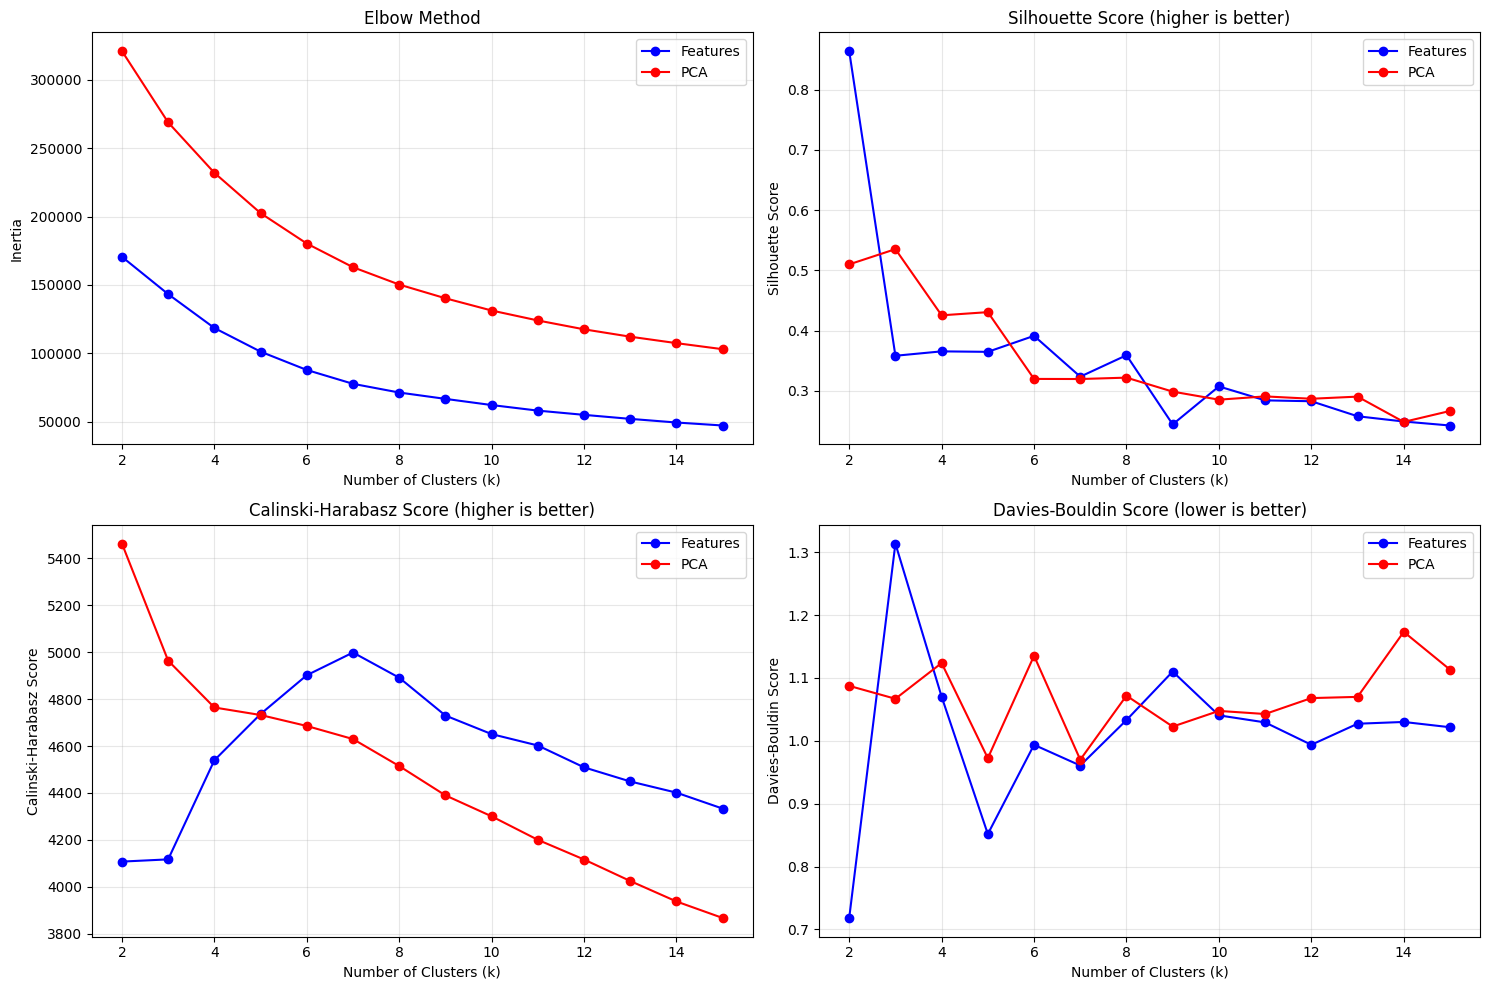

In [74]:
# ### 3.3 Plot Metrics to Find Optimal k

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow method (inertia)
axes[0, 0].plot(metrics_features['k'], metrics_features['inertia'], 'bo-', label='Features')
axes[0, 0].plot(metrics_pca['k'], metrics_pca['inertia'], 'ro-', label='PCA')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Silhouette score
axes[0, 1].plot(metrics_features['k'], metrics_features['silhouette'], 'bo-', label='Features')
axes[0, 1].plot(metrics_pca['k'], metrics_pca['silhouette'], 'ro-', label='PCA')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (higher is better)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz score
axes[1, 0].plot(metrics_features['k'], metrics_features['calinski'], 'bo-', label='Features')
axes[1, 0].plot(metrics_pca['k'], metrics_pca['calinski'], 'ro-', label='PCA')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz Score (higher is better)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin score
axes[1, 1].plot(metrics_features['k'], metrics_features['davies'], 'bo-', label='Features')
axes[1, 1].plot(metrics_pca['k'], metrics_pca['davies'], 'ro-', label='PCA')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].set_title('Davies-Bouldin Score (lower is better)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:
# ### 3.4 Choose Optimal k
# Find best k according to each metric

best_k_silhouette_features = metrics_features['k'][np.argmax(metrics_features['silhouette'])]
best_k_silhouette_pca = metrics_pca['k'][np.argmax(metrics_pca['silhouette'])]

best_k_davies_features = metrics_features['k'][np.argmin(metrics_features['davies'])]
best_k_davies_pca = metrics_pca['k'][np.argmin(metrics_pca['davies'])]

print("\n" + "="*60)
print("OPTIMAL K SELECTION")
print("="*60)
print(f"\n Based on Silhouette Score:")
print(f"   - Features: k={best_k_silhouette_features}")
print(f"   - PCA: k={best_k_silhouette_pca}")
print(f"\n Based on Davies-Bouldin Score:")
print(f"   - Features: k={best_k_davies_features}")
print(f"   - PCA: k={best_k_davies_pca}")

# Choose a final k (you can adjust based on interpretation)
final_k = 5  # Based on PCA results and interpretability
print(f"\n Selected k = {final_k} for final clustering")




OPTIMAL K SELECTION

 Based on Silhouette Score:
   - Features: k=2
   - PCA: k=3

 Based on Davies-Bouldin Score:
   - Features: k=2
   - PCA: k=7

 Selected k = 5 for final clustering


In [76]:
### 4. Perform Final Clustering
# Fit K-means with final k on both datasets


kmeans_features = KMeans(n_clusters=final_k, random_state=RANDOM_SEED, n_init=10)
kmeans_pca = KMeans(n_clusters=final_k, random_state=RANDOM_SEED, n_init=10)

labels_features = kmeans_features.fit_predict(X_features)
labels_pca = kmeans_pca.fit_predict(X_pca)

# Add labels to dataframes
features_norm['cluster_features'] = labels_features
pca_results['cluster_pca'] = labels_pca


 Cluster Profiles:
                    ID                            mean                    \
                  mean           std  count       mean        std  count   
cluster                                                                    
0        153601.972964  87966.545517   5733  14.072622  13.654490   5733   
1        153296.862036  88331.840087  11561   6.874656   4.782044  11561   
2        146023.571429  90564.224215     84   0.587138   1.884384     84   
3         43713.000000           NaN      1   0.041614        NaN      1   
4        143948.875000  89340.566440    168   0.100623   0.554136    168   

                cv                    skewness  ... n_peaks peak_height_ratio  \
              mean       std  count       mean  ...   count              mean   
cluster                                         ...                             
0         0.731803  0.517021   5733   1.375277  ...    5733          4.355178   
1         0.404006  0.233186  11561   0.953952 

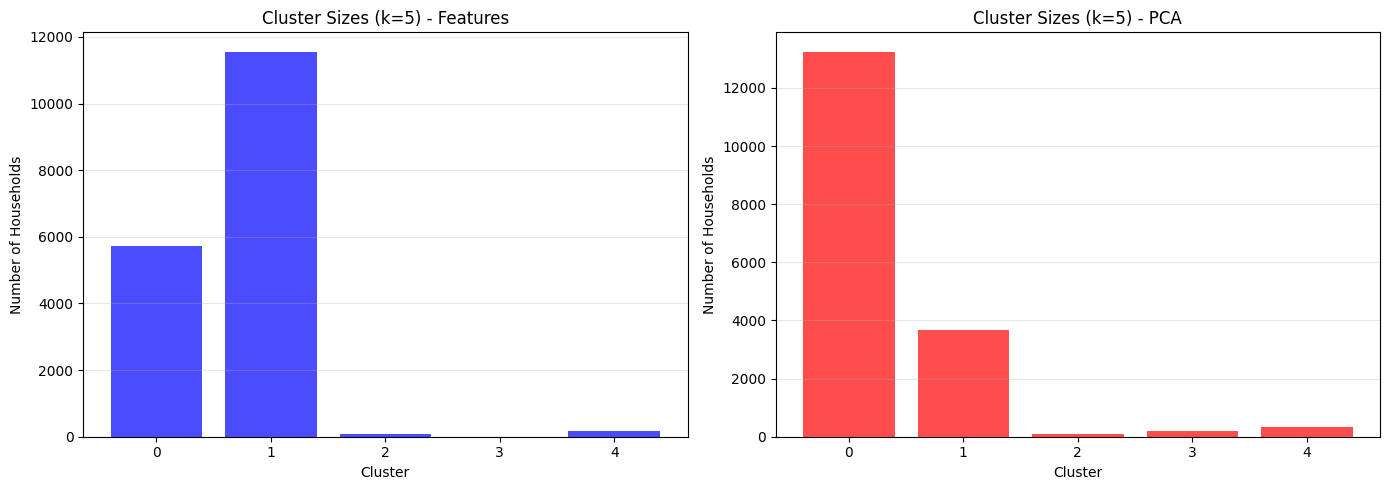

In [77]:
# ## 5. Analyze Clusters
# Load original features for interpretation

original_features = pd.read_csv(PROCESSED_DATA_DIR / 'household_features_reduced.csv')

# Add cluster labels
original_features['cluster'] = labels_features

# Calculate cluster profiles
cluster_profiles = original_features.groupby('cluster').agg(['mean', 'std', 'count'])
print("\n Cluster Profiles:")
print(cluster_profiles)

# Visualize cluster sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Features clustering
size_features = original_features['cluster'].value_counts().sort_index()
axes[0].bar(size_features.index, size_features.values, color='blue', alpha=0.7)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Households')
axes[0].set_title(f'Cluster Sizes (k={final_k}) - Features')
axes[0].grid(True, alpha=0.3, axis='y')

# PCA clustering
size_pca = pca_results['cluster_pca'].value_counts().sort_index()
axes[1].bar(size_pca.index, size_pca.values, color='red', alpha=0.7)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Households')
axes[1].set_title(f'Cluster Sizes (k={final_k}) - PCA')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
# ## 7. Cluster Interpretation

print("\n" + "="*60)
print("CLUSTER INTERPRETATION")
print("="*60)

# Define the key features (all available in your dataframe)
key_features = [
    'mean', 'cv', 'skewness', 'kurtosis', 'weekend_ratio', 
    'summer_peak', 'winter_peak', 'trend_slope', 
    'seasonal_strength_weekly', 'n_peaks', 'peak_height_ratio',
    'zero_percentage', 'avg_zero_run'
]

print(f"Using {len(key_features)} features for interpretation")




for cluster in range(final_k):
    print(f"\n Cluster {cluster} ({size_features[cluster]} households, {size_features[cluster]/len(original_features)*100:.1f}%):")
    
    # Get mean values for this cluster
    cluster_data = original_features[original_features['cluster'] == cluster]
    means = cluster_data[key_features].mean()
    
    # Describe the cluster
    desc = []
    if means['mean'] > original_features['mean'].quantile(0.75):
        desc.append("high consumption")
    elif means['mean'] < original_features['mean'].quantile(0.25):
        desc.append("low consumption")
    
    if means['cv'] > original_features['cv'].quantile(0.75):
        desc.append("highly variable")
    
    if means['zero_percentage'] > 10:
        desc.append(f"{means['zero_percentage']:.1f}% zeros")
    
    if means['summer_peak'] > 1.1:
        desc.append("summer peak")
    if means['winter_peak'] > 1.1:
        desc.append("winter peak")
    
    if means['trend_slope'] > 0:
        desc.append("increasing trend")
    elif means['trend_slope'] < 0:
        desc.append("decreasing trend")
    
    if means['n_peaks'] > original_features['n_peaks'].quantile(0.75):
        desc.append("many peaks")
    
    print(f"   Characteristics: {', '.join(desc) if desc else 'average'}")
    print(f"   Mean consumption: {means['mean']:.2f}")
    print(f"   Zero percentage: {means['zero_percentage']:.2f}%")
    print(f"   Summer/Winter ratio: {means['summer_peak']:.2f} / {means['winter_peak']:.2f}")



CLUSTER INTERPRETATION
Using 13 features for interpretation

 Cluster 0 (5733 households, 32.7%):
   Characteristics: high consumption, highly variable, decreasing trend
   Mean consumption: 14.07
   Zero percentage: 2.61%
   Summer/Winter ratio: 0.65 / 1.00

 Cluster 1 (11561 households, 65.9%):
   Characteristics: increasing trend
   Mean consumption: 6.87
   Zero percentage: 0.75%
   Summer/Winter ratio: 0.96 / 1.00

 Cluster 2 (84 households, 0.5%):
   Characteristics: low consumption, highly variable, 70.3% zeros, increasing trend
   Mean consumption: 0.59
   Zero percentage: 70.30%
   Summer/Winter ratio: 0.97 / 1.00

 Cluster 3 (1 households, 0.0%):
   Characteristics: low consumption, highly variable, 97.5% zeros, increasing trend
   Mean consumption: 0.04
   Zero percentage: 97.53%
   Summer/Winter ratio: 0.00 / 1.00

 Cluster 4 (168 households, 1.0%):
   Characteristics: low consumption, 98.1% zeros, decreasing trend
   Mean consumption: 0.10
   Zero percentage: 98.14%
   Su

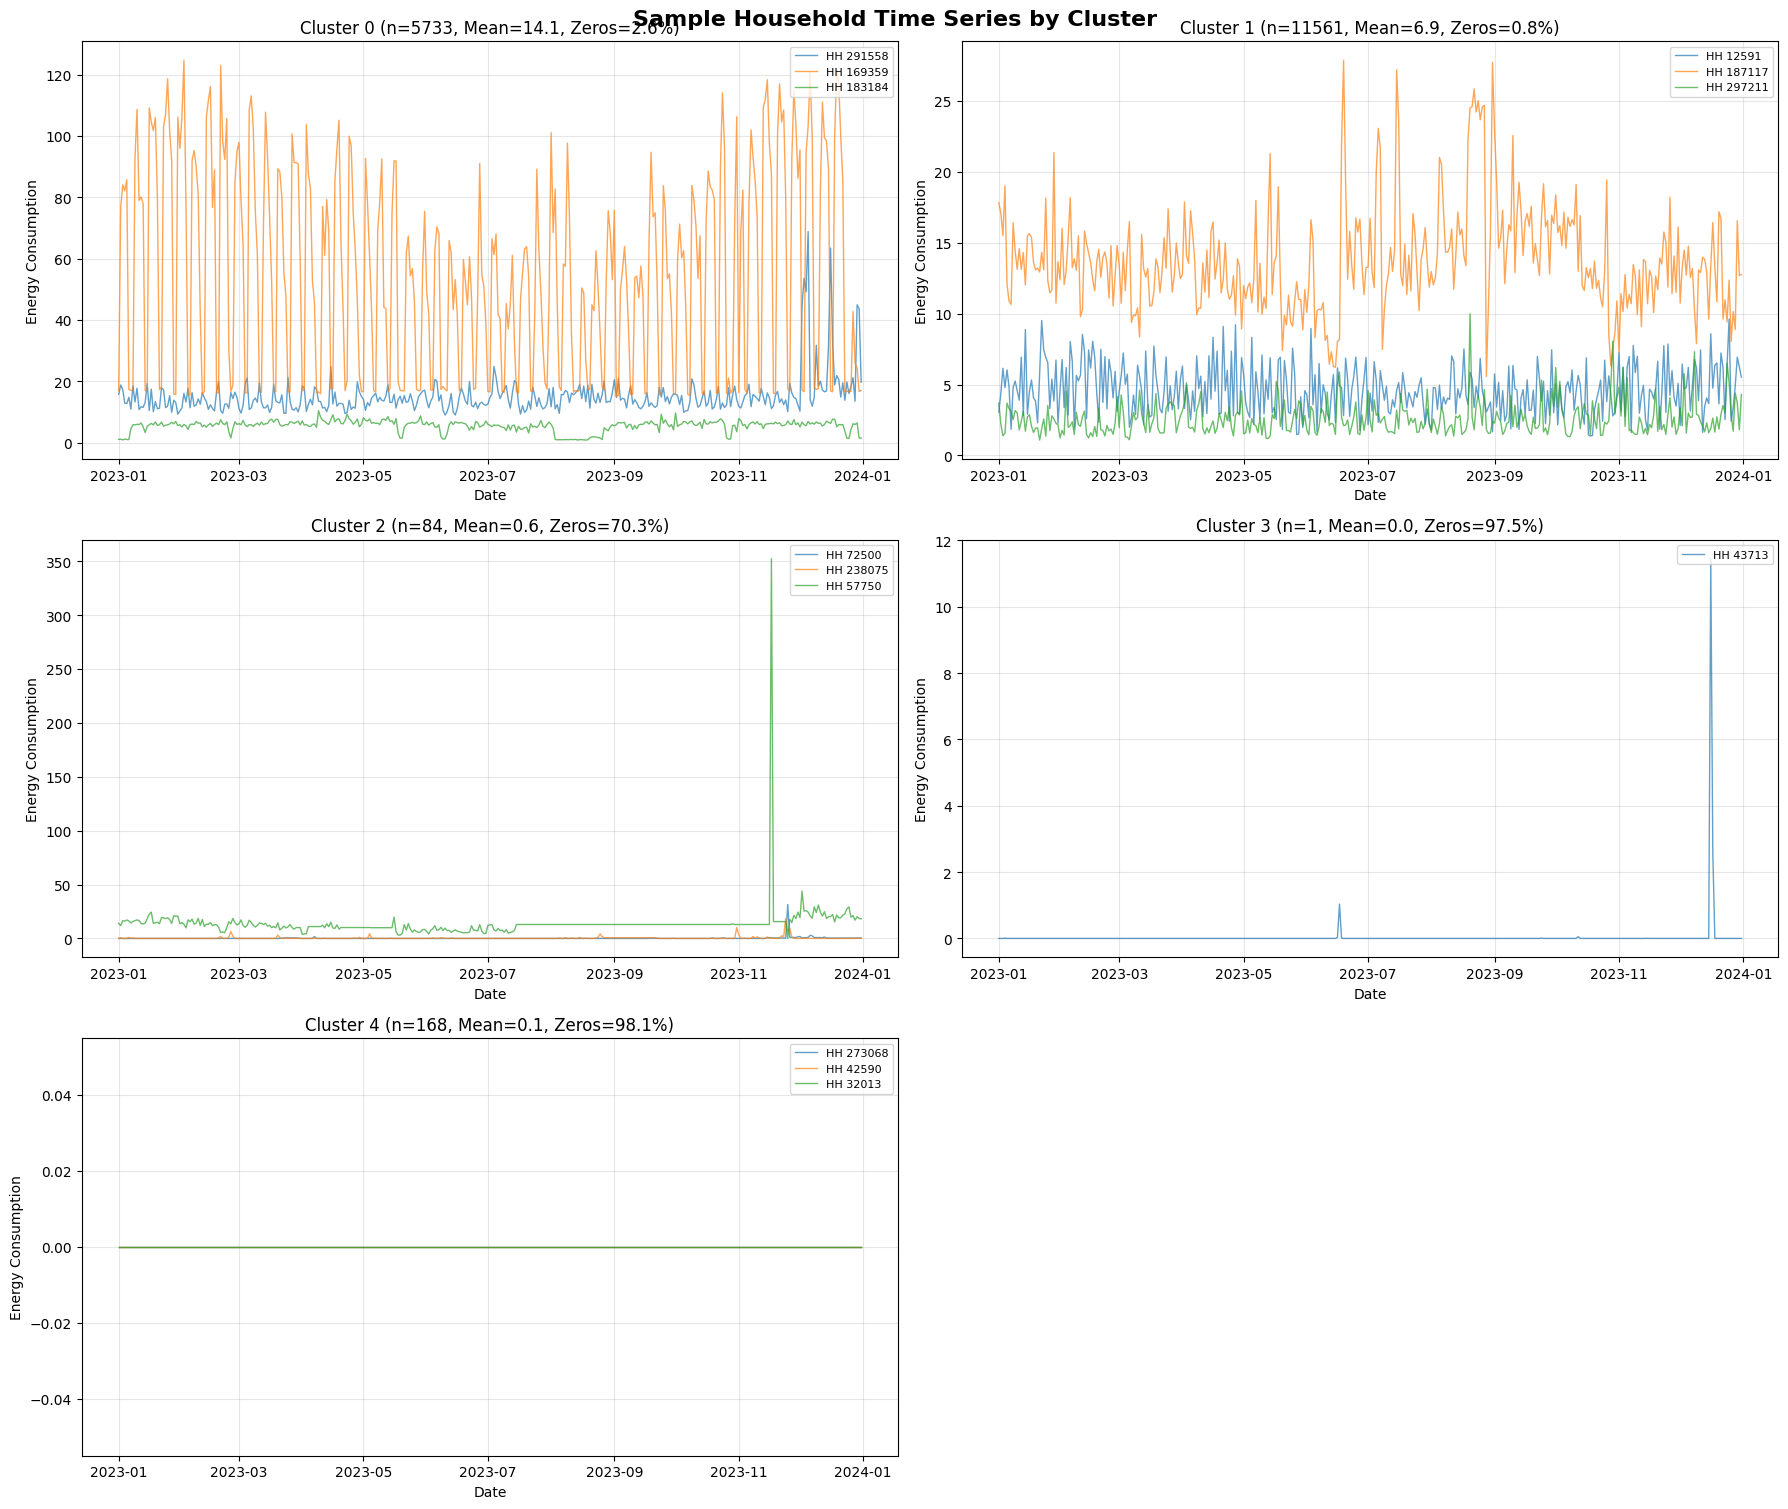

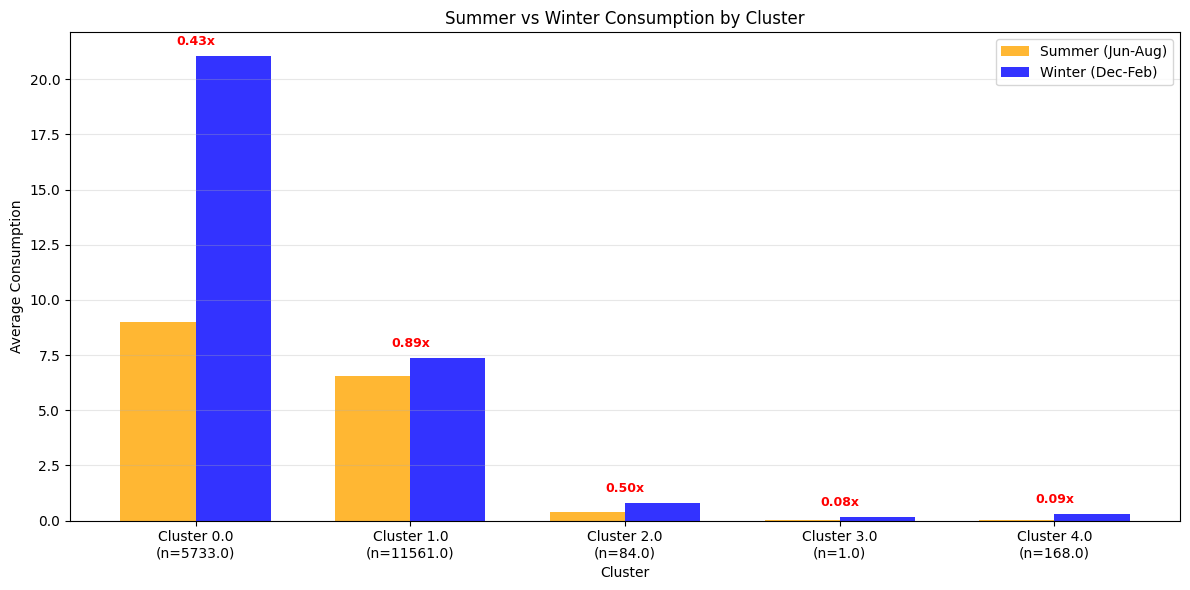

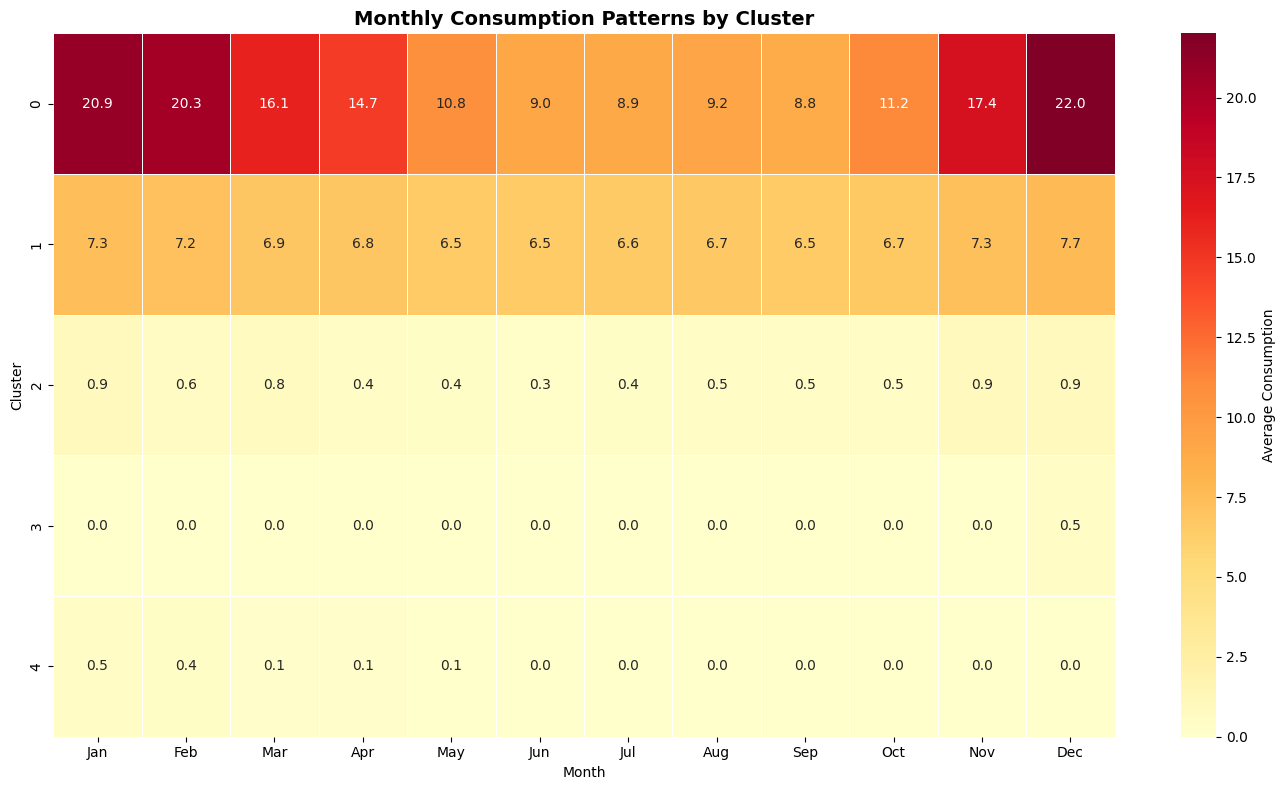

NameError: name 'MinMaxScaler' is not defined

In [79]:

# ## 11.  Cluster Visualizations

# %%
# Load the original data for visualization
df_2023 = pd.read_csv(RAW_DATA_DIR / 'sample_23.csv', index_col=0)
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')

# Get cluster assignments
cluster_assignments = original_features[['ID', 'cluster']].copy()

# Create a mapping of household ID to cluster
id_to_cluster = dict(zip(cluster_assignments['ID'], cluster_assignments['cluster']))

# Sample a few households from each cluster for visualization
np.random.seed(42)
sample_households = {}
for cluster in range(final_k):
    cluster_ids = cluster_assignments[cluster_assignments['cluster'] == cluster]['ID'].tolist()
    if len(cluster_ids) > 0:
        sample_households[cluster] = np.random.choice(cluster_ids, min(3, len(cluster_ids)), replace=False)

# %%
# ============================================================
# VISUALIZATION 1: Time Series by Cluster
# ============================================================
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for cluster in range(final_k):
    ax = axes[cluster]
    if cluster in sample_households:
        for hh_id in sample_households[cluster]:
            series = df_2023.loc[hh_id].values
            ax.plot(dates, series, linewidth=1, alpha=0.7, label=f'HH {hh_id}')
    
    # Add cluster statistics as title
    cluster_data = original_features[original_features['cluster'] == cluster]
    mean_consumption = cluster_data['mean'].mean()
    zero_pct = cluster_data['zero_percentage'].mean()
    
    ax.set_title(f'Cluster {cluster} (n={size_features[cluster]}, Mean={mean_consumption:.1f}, Zeros={zero_pct:.1f}%)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Energy Consumption')
    if cluster in sample_households:
        ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
if final_k < len(axes):
    for j in range(final_k, len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Sample Household Time Series by Cluster', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# VISUALIZATION 2: Seasonal Patterns by Cluster (Summer vs Winter)
# ============================================================

# Define seasons
summer_months = [6, 7, 8]  # June, July, August
winter_months = [12, 1, 2]  # December, January, February

# Calculate seasonal averages per cluster
cluster_seasonal = []

for cluster in range(final_k):
    cluster_ids = cluster_assignments[cluster_assignments['cluster'] == cluster]['ID'].tolist()
    
    if len(cluster_ids) > 0:
        # Get data for these households
        cluster_data = df_2023.loc[cluster_ids]
        
        # Calculate monthly averages - FIXED: Use transpose and groupby on columns
        # First, get date columns and extract months
        date_cols = cluster_data.columns
        months = [pd.to_datetime(col).month for col in date_cols]
        
        # Group by month across columns
        monthly_avg = cluster_data.T.groupby(months).mean().mean(axis=1)
        
        summer_avg = monthly_avg[[m for m in summer_months if m in monthly_avg.index]].mean()
        winter_avg = monthly_avg[[m for m in winter_months if m in monthly_avg.index]].mean()
        
        cluster_seasonal.append({
            'cluster': cluster,
            'summer': summer_avg,
            'winter': winter_avg,
            'ratio': summer_avg / winter_avg if winter_avg > 0 else 0,
            'size': size_features[cluster]
        })

df_seasonal = pd.DataFrame(cluster_seasonal)

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_seasonal))
width = 0.35

bars1 = ax.bar(x - width/2, df_seasonal['summer'], width, label='Summer (Jun-Aug)', color='orange', alpha=0.8)
bars2 = ax.bar(x + width/2, df_seasonal['winter'], width, label='Winter (Dec-Feb)', color='blue', alpha=0.8)

ax.set_xlabel('Cluster')
ax.set_ylabel('Average Consumption')
ax.set_title('Summer vs Winter Consumption by Cluster')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {row["cluster"]}\n(n={row["size"]})' for _, row in df_seasonal.iterrows()])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add ratio annotations
for i, row in df_seasonal.iterrows():
    ratio = row['ratio']
    color = 'green' if ratio > 1 else 'red'
    ax.annotate(f'{ratio:.2f}x', 
                xy=(i, max(row['summer'], row['winter']) + 0.5),
                ha='center', fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'summer_vs_winter_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# VISUALIZATION 3: Monthly Patterns by Cluster (Heatmap)
# ============================================================

# Calculate monthly averages for each cluster
monthly_data = []

for cluster in range(final_k):
    cluster_ids = cluster_assignments[cluster_assignments['cluster'] == cluster]['ID'].tolist()
    
    if len(cluster_ids) > 0:
        cluster_data = df_2023.loc[cluster_ids]
        
        # Get date columns and extract months
        date_cols = cluster_data.columns
        months = [pd.to_datetime(col).month for col in date_cols]
        
        # Group by month across columns
        monthly_avg = cluster_data.T.groupby(months).mean().mean(axis=1)
        
        for month in range(1, 13):
            monthly_data.append({
                'cluster': cluster,
                'month': month,
                'consumption': monthly_avg.get(month, 0)
            })

df_monthly = pd.DataFrame(monthly_data)

# Create pivot table for heatmap
pivot_monthly = df_monthly.pivot(index='cluster', columns='month', values='consumption')

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_monthly, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Consumption'},
            linewidths=0.5, ax=ax)

ax.set_xlabel('Month')
ax.set_ylabel('Cluster')
ax.set_title('Monthly Consumption Patterns by Cluster', fontsize=14, fontweight='bold')

# Add month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(month_names)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_patterns_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# VISUALIZATION 4: Cluster Characteristics Radar Chart (Simplified)
# ============================================================

# Create a simplified radar chart focusing on key seasonal features
seasonal_features = ['mean', 'cv', 'summer_peak', 'winter_peak', 'weekend_ratio', 'zero_percentage']

# Normalize features for radar chart
scaler_radar2 = MinMaxScaler()
features_radar2 = scaler_radar2.fit_transform(original_features[seasonal_features])

# Calculate cluster means
cluster_radar_means = []
for cluster in range(final_k):
    cluster_mask = original_features['cluster'] == cluster
    if cluster_mask.sum() > 0:
        cluster_means = np.mean(features_radar2[cluster_mask], axis=0)
    else:
        cluster_means = np.zeros(len(seasonal_features))
    cluster_radar_means.append(cluster_means)

# Create radar chart - adjust grid size based on number of clusters
n_cols = 4
n_rows = (final_k + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

angles = [n / len(seasonal_features) * 2 * pi for n in range(len(seasonal_features))]
angles += angles[:1]

for cluster in range(final_k):
    ax = axes[cluster]
    values = cluster_radar_means[cluster].tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, color='darkblue')
    ax.fill(angles, values, alpha=0.25, color='steelblue')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(seasonal_features, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster} (n={size_features[cluster]})')
    ax.grid(True)

# Hide unused subplots
for j in range(final_k, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cluster Characteristics (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_radar_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# VISUALIZATION 5: Consumption Distribution by Cluster (Boxplot)
# ============================================================

# Prepare data for boxplot
boxplot_data = []
cluster_labels = []

for cluster in range(final_k):
    cluster_ids = cluster_assignments[cluster_assignments['cluster'] == cluster]['ID'].tolist()
    if len(cluster_ids) > 0:
        cluster_values = df_2023.loc[cluster_ids].values.flatten()
        # Sample to avoid too many points
        if len(cluster_values) > 10000:
            cluster_values = np.random.choice(cluster_values, 10000, replace=False)
        boxplot_data.append(cluster_values)
        cluster_labels.append(f'Cluster {cluster}\n(n={size_features[cluster]})')

fig, ax = plt.subplots(figsize=(14, 7))
# FIXED: Changed 'labels' to 'tick_labels' to avoid deprecation warning
bp = ax.boxplot(boxplot_data, tick_labels=cluster_labels, patch_artist=True, showfliers=False)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(boxplot_data)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Cluster')
ax.set_ylabel('Energy Consumption')
ax.set_title('Distribution of Daily Consumption by Cluster', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add mean annotation
for i, cluster in enumerate(range(len(boxplot_data))):
    cluster_data = original_features[original_features['cluster'] == cluster]
    if len(cluster_data) > 0:
        mean_val = cluster_data['mean'].mean()
        ax.annotate(f'Mean: {mean_val:.1f}', 
                    xy=(i+1, mean_val), 
                    ha='center', va='bottom', fontsize=9, 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'consumption_distribution_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# VISUALIZATION 6: Cluster Summary Table (Text-based)
# ============================================================

print("\n" + "="*80)
print("CLUSTER SUMMARY TABLE")
print("="*80)

# Create summary table
summary_data = []
for cluster in range(final_k):
    cluster_data = original_features[original_features['cluster'] == cluster]
    if len(cluster_data) > 0:
        summary_data.append({
            'Cluster': cluster,
            'Size': size_features[cluster],
            'Percentage': f"{size_features[cluster]/len(original_features)*100:.1f}%",
            'Mean Cons.': f"{cluster_data['mean'].mean():.2f}",
            'CV': f"{cluster_data['cv'].mean():.2f}",
            'Zero %': f"{cluster_data['zero_percentage'].mean():.1f}%",
            'Summer/Winter': f"{cluster_data['summer_peak'].mean():.2f} / {cluster_data['winter_peak'].mean():.2f}",
            'Trend': "↑" if cluster_data['trend_slope'].mean() > 0 else "↓"
        })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# %%
# ============================================================
# VISUALIZATION 7: Cluster Pie Chart
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Define colors and explode for small clusters
colors = plt.cm.Set3(np.linspace(0, 1, final_k))
explode = [0.05 if size < 1000 else 0 for size in size_features.values]

# Filter out zero sizes
non_zero_sizes = [s for s in size_features.values if s > 0]
non_zero_labels = [f'Cluster {c}' for c, s in zip(size_features.index, size_features.values) if s > 0]

wedges, texts, autotexts = ax.pie(
    non_zero_sizes, 
    labels=non_zero_labels,
    autopct='%1.1f%%',
    colors=colors[:len(non_zero_sizes)],
    explode=explode[:len(non_zero_sizes)],
    shadow=True,
    startangle=90
)

# Format percentage text
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Household Distribution Across Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
print("\n✅ All enhanced visualizations saved to:", FIGURES_DIR)

In [80]:

# ## 8. Compare Features vs PCA Clustering
# Check agreement between feature-based and PCA-based clustering

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(labels_features, labels_pca)
nmi = normalized_mutual_info_score(labels_features, labels_pca)

print("\n" + "="*60)
print("CLUSTERING COMPARISON")
print("="*60)
print(f"\n Agreement between Feature-based and PCA clustering:")
print(f"   - Adjusted Rand Index: {ari:.3f} (0 = random, 1 = perfect match)")
print(f"   - Normalized Mutual Info: {nmi:.3f}")

if ari > 0.7:
    print("    High agreement - both approaches find similar structures")
elif ari > 0.4:
    print("    Moderate agreement - some overlap but differences")
else:
    print("    Low agreement - approaches capture different patterns")



CLUSTERING COMPARISON

 Agreement between Feature-based and PCA clustering:
   - Adjusted Rand Index: 0.476 (0 = random, 1 = perfect match)
   - Normalized Mutual Info: 0.411
    Moderate agreement - some overlap but differences


In [82]:
# ## 9. Save Results
# Save cluster assignments

original_features.to_csv(CLUSTERING_OUTPUT_DIR / 'cluster_assignments_features.csv', index=False)
pca_results.to_csv(CLUSTERING_OUTPUT_DIR / 'cluster_assignments_pca.csv', index=False)

# Save cluster profiles
cluster_profiles.to_csv(CLUSTERING_OUTPUT_DIR / 'cluster_profiles.csv')

# Save clustering model
import joblib
joblib.dump(kmeans_features, CLUSTERING_OUTPUT_DIR / 'kmeans_features_model.pkl')
joblib.dump(kmeans_pca, CLUSTERING_OUTPUT_DIR / 'kmeans_pca_model.pkl')

print(f"\n All clustering results saved to: {CLUSTERING_OUTPUT_DIR}")



 All clustering results saved to: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/clustering


In [83]:

# ## 10. Summary

print("\n" + "="*60)
print("CLUSTERING SUMMARY")
print("="*60)
print(f"\n Dataset: {len(original_features)} households")
print(f" Number of clusters: {final_k}")
print(f"\n Cluster sizes:")
for cluster in range(final_k):
    size = size_features[cluster]
    pct = size/len(original_features)*100
    print(f"   Cluster {cluster}: {size} households ({pct:.1f}%)")

print(f"\n Results saved to: {CLUSTERING_OUTPUT_DIR}")
print("\n" + "="*60)
print("CLUSTERING COMPLETE")
print("="*60)


CLUSTERING SUMMARY

 Dataset: 17547 households
 Number of clusters: 5

 Cluster sizes:
   Cluster 0: 5733 households (32.7%)
   Cluster 1: 11561 households (65.9%)
   Cluster 2: 84 households (0.5%)
   Cluster 3: 1 households (0.0%)
   Cluster 4: 168 households (1.0%)

 Results saved to: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/clustering

CLUSTERING COMPLETE
